In [17]:
!pip install torch
import torch
import torch.nn as nn
import numpy as np

class UniversalScatteringPINN(nn.Module):
    def __init__(self):
        super(UniversalScatteringPINN, self).__init__()
        # Input: s (energy squared)
        # Output: [Real(A), Imag(A)]
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 2) 
        )

    def forward(self, s):
        return self.net(s)

def Kallen_Lambda(a, b, c):
    """ The triangle function used for flux factors """
    return a**2 + b**2 + c**2 - 2*a*b - 2*a*c - 2*b*c

def physics_informed_loss(model, s_data, sigma_data, m1, m2):
    # 1. Prediction from NN
    preds = model(s_data)
    Re_A = preds[:, 0:1]
    Im_A = preds[:, 1:2]

    # 2. Data Loss: Compare predicted sigma to experimental sigma
    # Using the Optical Theorem: sigma = Im(A) / flux
    # flux = sqrt(lambda(s, m1^2, m2^2))
    flux = torch.sqrt(Kallen_Lambda(s_data, m1**2, m2**2))
    sigma_pred = Im_A / flux
    
    loss_data = torch.mean((sigma_pred - sigma_data)**2)

    # 3. Physics Loss: Analyticity (Dispersion Relations)
    # This is a simplified placeholder for the Kramers-Kronig relation
    # d/ds Re(A) should relate to integral of Im(A). 
    # For now, we penalize non-smooth behavior or unphysical negatives.
    loss_reg = torch.mean(torch.relu(-Im_A)) # Im(A) must be positive for sigma > 0

    return loss_data + 0.1 * loss_reg

# --- Example Usage ---
# Particle Masses (e.g., Proton and Pion+)
m_p = 0.938 # GeV
m_pi = 0.139 # GeV

# Mock Data: s values and corresponding experimental cross sections
s_train = torch.linspace((m_p + m_pi)**2 + 0.1, 10, 100).view(-1, 1)
sigma_train = torch.exp(-s_train) + 0.5 # Mock falling cross section

model = UniversalScatteringPINN()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(1000):
    optimizer.zero_grad()
    loss = physics_informed_loss(model, s_train, sigma_train, m_p, m_pi)
    loss.backward()
    optimizer.step()
    
    if epoch % 200 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Epoch 0, Loss: 0.595744
Epoch 200, Loss: 0.007452
Epoch 400, Loss: 0.001165
Epoch 600, Loss: 0.000325
Epoch 800, Loss: 0.000175


In [3]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# --- 1. DATA LOADING (Tailored to your .dat snippet) ---
def load_particle_data(filepath):
    plab_list = []
    sigma_list = []
    
    with open(filepath, 'r') as f:
        # Skip the header lines until we reach the data
        start_reading = False
        for line in f:
            if '---' in line:
                start_reading = True
                continue
            if not start_reading:
                continue
            
            parts = line.split()
            if len(parts) < 5: continue # Skip malformed lines
            
            try:
                # Based on your snippet:
                # Index 0: Point Number | Index 1: PLAB | Index 4: SIG(MB)
                p_val = float(parts[1]) 
                sigma_val = float(parts[4])
                
                plab_list.append(p_val)
                sigma_list.append(sigma_val)
            except (ValueError, IndexError):
                continue
    
    plab = torch.tensor(plab_list, dtype=torch.float32).view(-1, 1)
    sigma = torch.tensor(sigma_list, dtype=torch.float32).view(-1, 1)
    
    # Sort for smooth plotting
    idx = torch.argsort(plab, dim=0).squeeze()
    return plab[idx], sigma[idx]

# --- 2. THE UNIVERSAL PINN MODEL ---
class ScatteringPINN(nn.Module):
    def __init__(self):
        super().__init__()
        # Input: [s, m1, m2]
        self.net = nn.Sequential(
            nn.Linear(3, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 2) # [Real(A), Imag(A)]
        )

    def forward(self, plab, m1, m2):
        # Relativistic Kinematics: s = m1^2 + m2^2 + 2*m2*E_lab
        # E_lab = sqrt(plab^2 + m1^2)
        e_lab = torch.sqrt(plab**2 + m1**2)
        s = m1**2 + m2**2 + 2*m2*e_lab
        
        m1_vec = torch.full_like(s, m1)
        m2_vec = torch.full_like(s, m2)
        x = torch.cat([s, m1_vec, m2_vec], dim=1)
        return self.net(x), s

# --- 3. TRAINING AND PLOTTING ---
def train_and_plot(filepath, m1, m2, label="pi+ p"):
    plab_phys, sigma_phys = load_particle_data(filepath)
    print(f"Loaded {len(plab_phys)} data points.")
    
    model = ScatteringPINN()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    
    for epoch in range(1001):
        optimizer.zero_grad()
        preds, s_computed = model(plab_phys, m1, m2)
        Im_A = preds[:, 1:2]
        
        # Physics Constraint: sigma = Im(A) / flux
        # Kallen lambda in s-channel
        lambda_kin = s_computed**2 + m1**4 + m2**4 - 2*s_computed*m1**2 - 2*s_computed*m2**2 - 2*m1**2*m2**2
        flux = torch.sqrt(torch.clamp(lambda_kin, min=1e-9))
        
        sigma_pred = Im_A / flux
        loss = torch.mean((sigma_pred - sigma_phys)**2)
        
        loss.backward()
        optimizer.step()
        
        if epoch % 200 == 0:
            print(f"Epoch {epoch} | Loss: {loss.item():.4f}")

    # --- FINAL PLOT ---
    plt.figure(figsize=(10, 6))
    plt.scatter(plab_phys.numpy(), sigma_phys.numpy(), color='blue', alpha=0.4, label='PDG Data', s=15)
    plt.plot(plab_phys.numpy(), sigma_pred.detach().numpy(), color='red', label='PINN Fit', linewidth=2)
    
    plt.xlabel(r'$P_{lab}$ (GeV/c)')
    plt.ylabel(r'$\sigma_{tot}$ (mb)')
    plt.title(f'Universal Scattering Model: {label}')
    plt.xscale('log')
    plt.yscale('log')
    plt.grid(True, which="both", alpha=0.3)
    plt.legend()
    plt.show()

# --- RUN ---
m_pion = 0.13957
m_proton = 0.93827
# filePath = r"/home/ekremdemiray/pPiPlusTotalScattering.dat"
# train_and_plot(filePath, m_pion, m_proton, r"$\pi^+ p \to X$")

In [12]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib as mpl

class PurePlabPINN(nn.Module):
    def __init__(self):
        super().__init__()
        # Input: [log10(Plab), m1, m2]
        # We still keep m1 and m2 so it works for "all particles"
        self.net = nn.Sequential(
            nn.Linear(3, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 1) # Output: log10(Sigma)
        )

    def forward(self, plab, m1, m2):
        # Neural Network input: raw Log10 of the Lab Momentum
        x_in = torch.log10(plab)
        m1_vec = torch.full_like(plab, m1)
        m2_vec = torch.full_like(plab, m2)
        
        combined_input = torch.cat([x_in, m1_vec, m2_vec], dim=1)
        
        # Predicted log10(sigma)
        return self.net(combined_input)

def train_and_plot(filepath, m1, m2):
    plab_phys, sigma_phys = load_particle_data(filepath)
    
    model = PurePlabPINN()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    
    target_log_sigma = torch.log10(sigma_phys)

    for epoch in range(3001):
        optimizer.zero_grad()
        
        log_sigma_pred = model(plab_phys, m1, m2)
        
        loss = torch.mean((log_sigma_pred - target_log_sigma)**2)
        
        loss.backward()
        optimizer.step()

    # --- Plotting ---
    plt.figure(figsize=(10, 6))
    plt.scatter(plab_phys.numpy(), sigma_phys.numpy(), color='blue', alpha=0.3)
    
    plt.plot(plab_phys.numpy(), 10**log_sigma_pred.detach().numpy(), color='red')

    # plt.xlim(0,5)
    # plt.ylim(1.5,250)
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel(r'$P_{lab}$ (GeV/c)')
    plt.ylabel(r'$\sigma_{tot}$ (mb)')
    plt.title(r'Total Scattering Cross Section for Proton-Proton  ')
    plt.savefig("FullRegion_loglog_ProtonProton.jpg")
    plt.show()


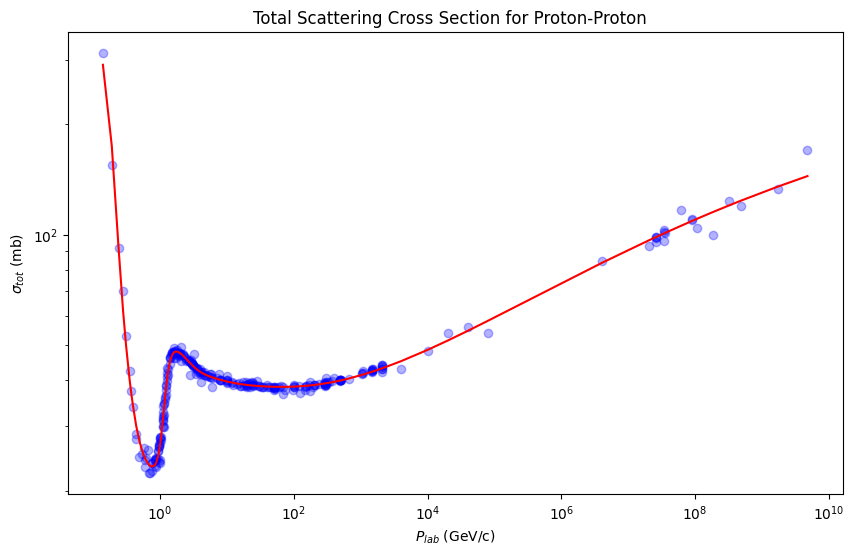

In [13]:
m_pion = 0.13957
m_proton = 0.93827
fname = "/home/ekremdemiray/DataFilesForScatteringExperiments/ppDataFromPDG.dat"  

filePath = r"/home/ekremdemiray/DataFilesForScatteringExperiments/ppDataFromPDG.dat"
train_and_plot(fname,m_proton,m_proton)

Epoch 0: Loss 3.672178
Epoch 1000: Loss 0.010627
Epoch 2000: Loss 0.010393
Epoch 3000: Loss 0.010124


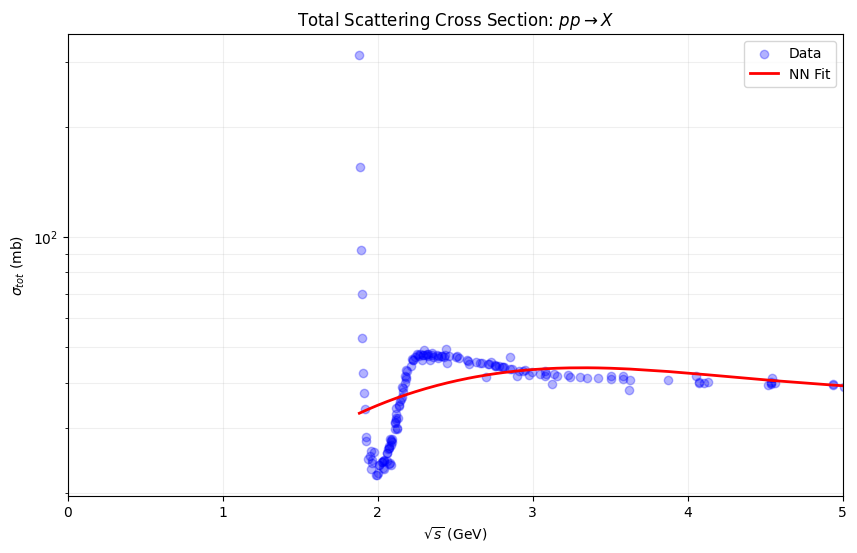

In [65]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

class SqrtSPINN(nn.Module):
    def __init__(self):
        super().__init__()
        # Input: [log10(sqrt_s), m1, m2]
        self.net = nn.Sequential(
            nn.Linear(3, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 1) # Output: log10(Sigma)
        )

    def forward(self, sqrt_s, m1, m2):
        # 1. Ensure input is 2D [N, 1] for concatenation
        if sqrt_s.dim() == 1:
            sqrt_s = sqrt_s.unsqueeze(1)
            
        # 2. Use log10(sqrt_s) as the primary feature
        x_in = torch.log10(sqrt_s)
        m1_vec = torch.full_like(x_in, m1)
        m2_vec = torch.full_like(x_in, m2)
        
        combined_input = torch.cat([x_in, m1_vec, m2_vec], dim=1)
        return self.net(combined_input)

def train_and_plot(filepath, m1, m2):
    # Load original lab momentum data
    plab_phys, sigma_phys = load_particle_data(filepath)
    
    # 3. KINEMATIC CONVERSION: Plab -> sqrt(s)
    # Formula: s = m1^2 + m2^2 + 2 * m2 * sqrt(plab^2 + m1^2)
    e_lab = torch.sqrt(plab_phys**2 + m1**2)
    s_val = m1**2 + m2**2 + 2 * m2 * e_lab
    sqrt_s_phys = torch.sqrt(s_val)
    
    model = SqrtSPINN()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    
    # Ensure targets are [N, 1] to match model output shape
    target_log_sigma = torch.log10(sigma_phys).view(-1, 1)

    for epoch in range(3001):
        optimizer.zero_grad()
        
        # Train on sqrt_s
        log_sigma_pred = model(sqrt_s_phys, m1, m2)
        
        loss = torch.mean((log_sigma_pred - target_log_sigma)**2)
        loss.backward()
        optimizer.step()
        
        if epoch % 1000 == 0:
            print(f"Epoch {epoch}: Loss {loss.item():.6f}")

    # --- Plotting ---
    plt.figure(figsize=(10, 6))
    
    # Plotting against sqrt_s (Standard for HEP)
    x_plot = sqrt_s_phys.numpy()
    y_data = sigma_phys.numpy()
    y_pred = 10**log_sigma_pred.detach().numpy()

    plt.scatter(x_plot, y_data, color='blue', alpha=0.3, label='Data')
    plt.plot(x_plot, y_pred, color='red', linewidth=2, label='NN Fit')

    plt.xlim(0,5)
    # plt.xscale('log') # Log scale is essential for energy ranges
    plt.yscale('log')
    plt.xlabel(r'$\sqrt{s}$ (GeV)')
    plt.ylabel(r'$\sigma_{tot}$ (mb)')
    plt.title(r'Total Scattering Cross Section: $pp \to X$')
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.show()
    
m_pion = 0.13957
m_proton = 0.93827
fname = "/home/ekremdemiray/DataFilesForScatteringExperiments/ppDataFromPDG.dat"  

filePath = r"/home/ekremdemiray/DataFilesForScatteringExperiments/ppDataFromPDG.dat"
train_and_plot(fname,m_proton,m_proton)